### Step 1 - Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import warnings


warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (13, 5)

### Step - 2 Load data

In [2]:
rfm = pd.read_csv('../data/rfm_clv.csv')
df  = pd.read_csv('../data/clean_data.csv', parse_dates=['InvoiceDate'])


seg_colors = {'Champions': '#1D9E75', 'Loyal Customers': '#378ADD', 'Lost / Inactive': '#888780'}
print(f"Loaded: {len(rfm):,} customers across {rfm['Segment'].nunique()} segments")

Loaded: 5,878 customers across 3 segments


In [3]:
# RFM Data Preview
rfm.head(10)


,Customer ID,Recency,Frequency,Monetary,Cluster,Segment,predicted_purchases_12m,CLV_12m
0,12346,326,12,77556.46,1,Loyal Customers,2.471506,25962.373049
1,12347,2,8,5633.32,1,Loyal Customers,5.841563,3981.252162
2,12348,75,5,2019.40,1,Loyal Customers,3.244333,1413.954074
3,12349,19,4,4428.69,1,Loyal Customers,1.977177,2179.239819
4,12350,310,1,334.40,0,Lost / Inactive,0.000000,0.000000
5,12351,375,1,300.93,0,Lost / Inactive,0.000000,0.000000
6,12352,36,10,2849.84,1,Loyal Customers,6.742408,2161.109558
7,12353,204,2,406.76,0,Lost / Inactive,1.045127,108.757026
8,12354,232,1,1079.40,1,Loyal Customers,0.000000,0.000000
9,12355,214,2,947.61,1,Loyal Customers,0.815141,423.775904


In [4]:
# Clean Data Preview
df.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalRevenue,YearMonth
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009-12
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085,United Kingdom,39.6,2009-12
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009-12
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085,United Kingdom,59.5,2009-12
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085,United Kingdom,30.6,2009-12
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085,United Kingdom,45.0,2009-12


### Insight 1 — Revenue concentration

In [5]:
# Group customers by segment and calculate key business metrics
seg_rev = rfm.groupby('Segment').agg(
    Customers=('Customer ID', 'count'),      # Number of customers in each segment
    Total_Revenue=('Monetary', 'sum'),       # Total historical revenue from each segment
    Avg_CLV=('CLV_12m', 'mean')              # Average predicted 12-month CLV per segment
)

# Round numeric values to 1 decimal place for cleaner output
seg_rev = seg_rev.round(1)

# Calculate each segment's share of total revenue
seg_rev['Revenue_%'] = (
    seg_rev['Total_Revenue'] / seg_rev['Total_Revenue'].sum() * 100
).round(1)

# Calculate each segment's share of total customers
seg_rev['Customer_%'] = (
    seg_rev['Customers'] / seg_rev['Customers'].sum() * 100
).round(1)

# Display the final segment revenue table
print("Revenue and customer breakdown by segment:")
print(seg_rev)

# Extract the Champions row for a focused business insight
champions = seg_rev.loc['Champions']

# Print a clear insight comparing customer share vs revenue share
print()
print(
    f"Champions: {champions['Customer_%']}% of customers "
    f"generate {champions['Revenue_%']}% of revenue"
)

# Business interpretation
print("This shows that a small high-value segment contributes a large share of revenue.")

Revenue and customer breakdown by segment:
                 Customers  Total_Revenue  Avg_CLV  Revenue_%  Customer_%
Segment                                                                  
Champions               24      3237553.9  55447.1       18.2         0.4
Lost / Inactive       2283      1240615.8     96.7        7.0        38.8
Loyal Customers       3571     13265259.5   2007.8       74.8        60.8

Champions: 0.4% of customers generate 18.2% of revenue
This shows that a small high-value segment contributes a large share of revenue.


### Insight 2 - Future revenue Potential(CLV)

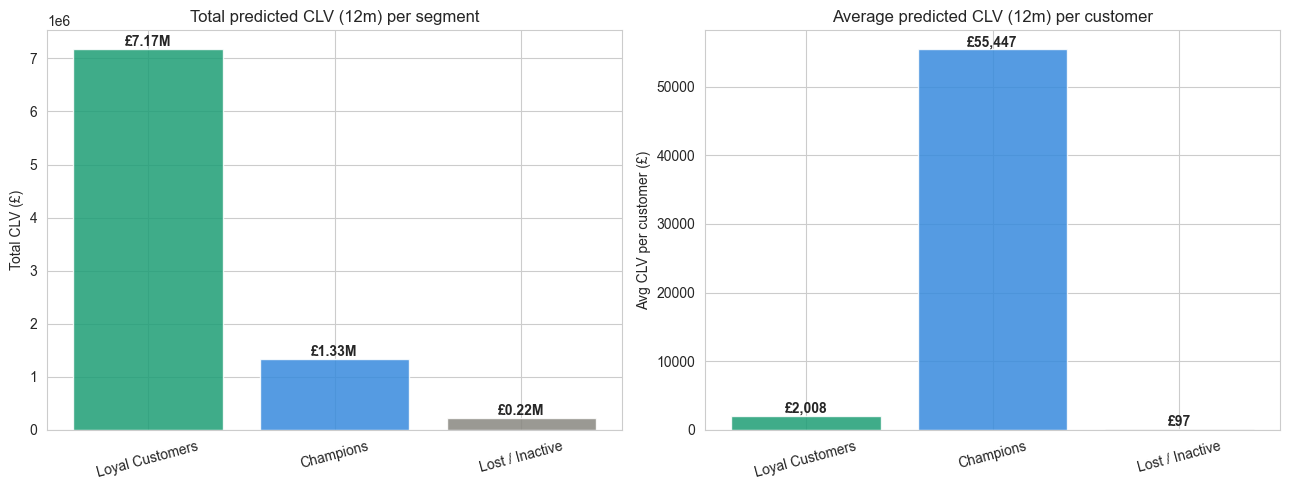

In [8]:
# Create CLV summary by customer segment
clv_summary = rfm.groupby('Segment').agg(
    Total_CLV=('CLV_12m', 'sum'),
    Avg_CLV=('CLV_12m', 'mean')
)

# Sort segments by total CLV from highest to lowest
clv_summary = clv_summary.sort_values('Total_CLV', ascending=False)

# Create colors automatically
colors = ['#1D9E75', '#378ADD', '#888780']

# Create two side-by-side charts
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot total predicted CLV by segment
axes[0].bar(clv_summary.index, clv_summary['Total_CLV'], color=colors, alpha=0.85)
axes[0].set_title('Total predicted CLV (12m) per segment')
axes[0].set_ylabel('Total CLV (£)')

# Add labels above total CLV bars
for i, value in enumerate(clv_summary['Total_CLV']):
    axes[0].text(
        i,
        value,
        f'£{value/1e6:.2f}M',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

# Plot average predicted CLV by segment
axes[1].bar(clv_summary.index, clv_summary['Avg_CLV'], color=colors, alpha=0.85)
axes[1].set_title('Average predicted CLV (12m) per customer')
axes[1].set_ylabel('Avg CLV per customer (£)')

# Add labels above average CLV bars
for i, value in enumerate(clv_summary['Avg_CLV']):
    axes[1].text(
        i,
        value,
        f'£{value:,.0f}',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

# Rotate x-axis labels slightly for readability
for ax in axes:
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

### Insight 3 - Seasonality and purchase timing

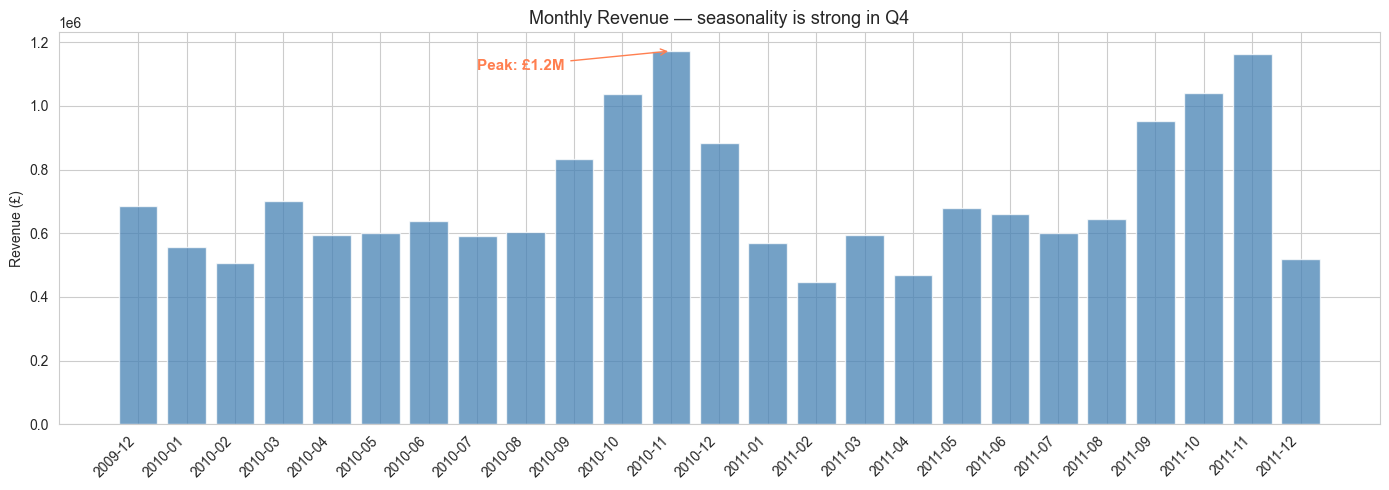

In [12]:
# Create a monthly period column from the invoice date
# Example: 2011-11-15 becomes 2011-11
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M').astype(str)

# Calculate total revenue for each month
monthly = (
    df.groupby('YearMonth')['TotalRevenue']
      .sum()
      .reset_index()
)

# Create figure and axis for the bar chart
fig, ax = plt.subplots(figsize=(14, 5))

# Plot monthly revenue as a bar chart
ax.bar(
    monthly['YearMonth'],          # x-axis: month
    monthly['TotalRevenue'],       # y-axis: total revenue
    color='steelblue',
    alpha=0.75,
    edgecolor='white'
)

# Add chart title and axis labels
ax.set_title('Monthly Revenue — seasonality is strong in Q4', fontsize=13)
ax.set_ylabel('Revenue (£)')
ax.set_xlabel('')

# Rotate month labels for better readability
plt.xticks(rotation=45, ha='right')

# Find the index of the highest monthly revenue
peak_idx = monthly['TotalRevenue'].idxmax()

# Add an annotation pointing to the highest revenue month
ax.annotate(
    f"Peak: £{monthly.loc[peak_idx, 'TotalRevenue'] / 1e6:.1f}M",
    xy=(peak_idx, monthly.loc[peak_idx, 'TotalRevenue']),        # arrow points here
    xytext=(peak_idx - 4, monthly['TotalRevenue'].max() * 0.95), # text location
    arrowprops=dict(arrowstyle='->', color='coral'),
    fontsize=11,
    color='coral',
    fontweight='bold'
)

# Improve layout spacing
plt.tight_layout()

# Display chart
plt.show()


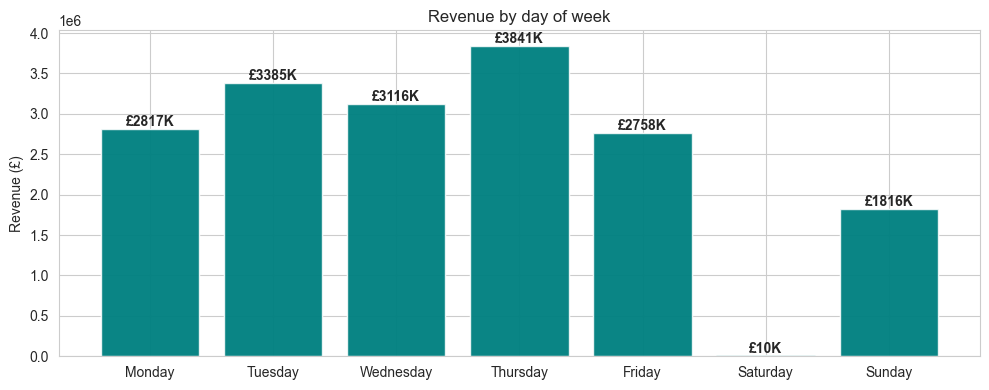

Highest revenue day: Thursday
Lowest revenue day:  Saturday


In [16]:
# Extract the day name from each invoice date
# Example: 2011-11-15 becomes Tuesday
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()

# Define the correct weekday order for plotting
day_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

# Calculate total revenue for each day of the week
daily = (
    df.groupby('DayOfWeek')['TotalRevenue']
      .sum()
      .reindex(day_order)
)

# Create the bar chart
fig, ax = plt.subplots(figsize=(10, 4))

# Plot revenue by weekday
ax.bar(
    daily.index,      # x-axis: weekday names
    daily.values,     # y-axis: revenue values
    color='teal',
    alpha=0.8
)

# Create bar chart
bars = ax.bar(daily.index, daily.values, color='teal', alpha=0.8)

# Add data labels above each bar
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,   # x-position: center of bar
        height,                              # y-position: top of bar
        f'£{height/1000:.0f}K',              # label format in thousands
        ha='center',
        va='bottom',
        fontweight='bold'
    )

# Add chart title and y-axis label
ax.set_title('Revenue by day of week')
ax.set_ylabel('Revenue (£)')

# Improve layout spacing
plt.tight_layout()

# Display chart
plt.show()

# Print highest and lowest revenue days
print(f"Highest revenue day: {daily.idxmax()}")
print(f"Lowest revenue day:  {daily.idxmin()}")

### Insight 4 - Recency risk: who is about to churn?

In [17]:
# Filter only customers who belong to the Loyal Customers segment
loyal = rfm[rfm['Segment'] == 'Loyal Customers'].copy()

# Identify Loyal Customers who have not purchased for more than 90 days
# These customers are at risk of becoming Lost / Inactive
at_risk = loyal[loyal['Recency'] > 90].sort_values(
    'CLV_12m',
    ascending=False
)

# Count how many Loyal Customers are currently at risk
print(f"Loyal customers with Recency > 90 days: {len(at_risk):,}")

# Calculate the total predicted 12-month CLV from these at-risk customers
print(f"Their total predicted CLV at risk:       £{at_risk['CLV_12m'].sum():,.0f}")

print()

# Display the highest-value at-risk customers first
print("Top 10 at-risk Loyal customers (highest CLV to protect):")

at_risk.head(10)[
    ['Customer ID', 'Recency', 'Frequency', 'Monetary', 'CLV_12m']
].round(2)

Loyal customers with Recency > 90 days: 794
Their total predicted CLV at risk:       £774,648

Top 10 at-risk Loyal customers (highest CLV to protect):


,Customer ID,Recency,Frequency,Monetary,CLV_12m
3371,15749,235,3,44534.30,26732.00
0,12346,326,12,77556.46,25962.37
1438,13802,139,19,26259.11,11174.60
3796,16180,100,13,16249.87,8331.25
678,13027,114,19,17335.20,7430.35
4166,16553,163,33,16644.01,6638.28
5677,18087,98,17,14761.52,6247.96
1203,13564,144,37,17249.55,5610.53
631,12980,158,21,16245.78,5517.75
2656,15032,256,8,13780.65,5317.44


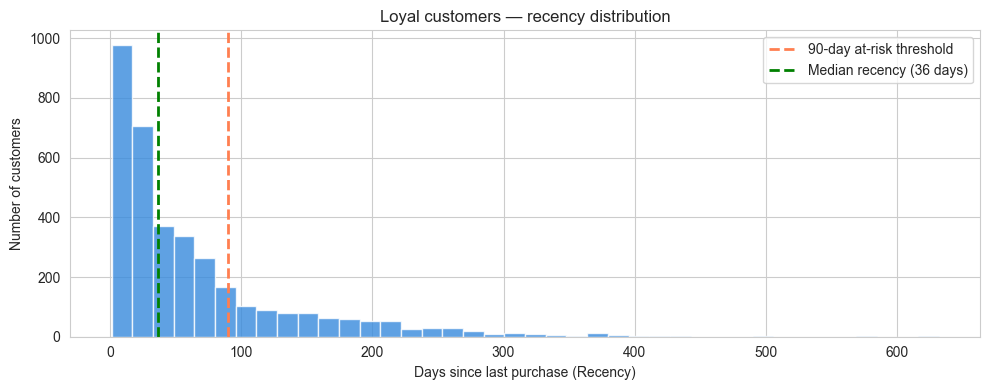

In [18]:
# Calculate median recency for Loyal Customers
median_recency = loyal['Recency'].median()

# Create histogram
plt.figure(figsize=(10, 4))

plt.hist(
    loyal['Recency'],
    bins=40,
    color='#378ADD',
    alpha=0.8,
    edgecolor='white'
)

# Add 90-day at-risk threshold line
plt.axvline(
    90,
    color='coral',
    linestyle='--',
    linewidth=2,
    label='90-day at-risk threshold'
)

# Add median recency line
plt.axvline(
    median_recency,
    color='green',
    linestyle='--',
    linewidth=2,
    label=f'Median recency ({median_recency:.0f} days)'
)

plt.title("Loyal customers — recency distribution")
plt.xlabel("Days since last purchase (Recency)")
plt.ylabel("Number of customers")
plt.legend()
plt.tight_layout()
plt.show()

### Insight 5 - Product mix by segment

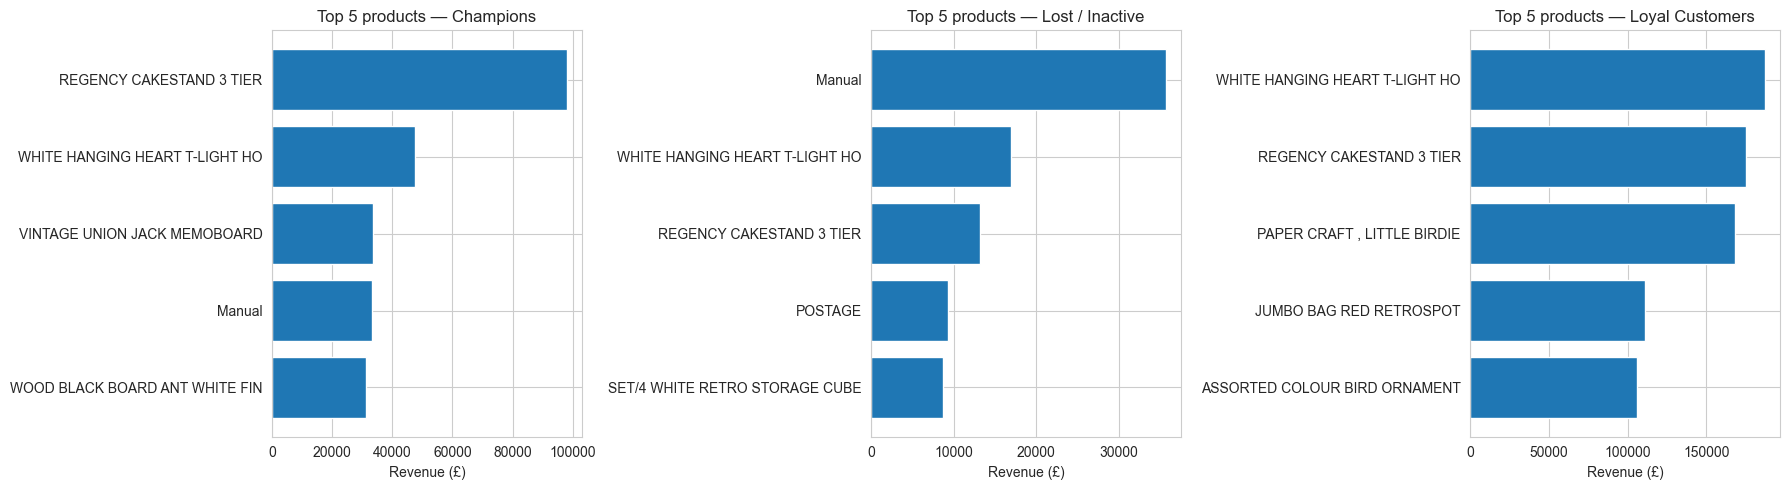

In [19]:
# Add customer segment to each transaction
tx_seg = df.merge(
    rfm[['Customer ID', 'Segment']],
    on='Customer ID',
    how='left'
)

# Calculate revenue by segment and product
product_revenue = (
    tx_seg.groupby(['Segment', 'Description'], as_index=False)['TotalRevenue']
          .sum()
)

# Define segment order
segments = product_revenue['Segment'].dropna().unique()

# Create charts
fig, axes = plt.subplots(1, len(segments), figsize=(18, 5))

# Plot top 5 products for each segment
for ax, segment in zip(axes, segments):

    # Get top 5 products for this segment
    top5 = (
        product_revenue[product_revenue['Segment'] == segment]
        .sort_values('TotalRevenue', ascending=False)
        .head(5)
    )

    # Plot horizontal bar chart
    ax.barh(
        top5['Description'].str[:30],
        top5['TotalRevenue']
    )

    ax.set_title(f'Top 5 products — {segment}')
    ax.set_xlabel('Revenue (£)')
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

### Final Summary

In [21]:
recommendations = {
    "Champions": {
        "risk": "Low risk — these customers buy often and spend the most",
        "priority": "1 — Keep them happy",
        "actions": [
            "Send thank-you emails after purchase",
            "Give early access to new products or seasonal offers",
            "Offer small loyalty discounts for repeat purchases",
            "Recommend similar products based on their past orders",
            "Ask for reviews because they are your best customers",
        ]
    },

    "Loyal Customers": {
        "risk": "Medium risk — they buy regularly but may stop if ignored",
        "priority": "2 — Encourage them to buy more",
        "actions": [
            "Send monthly emails with products they may like",
            "Offer free shipping or a small discount on their next order",
            "Send reminders if they have not bought for 90 days",
            "Promote related products to increase basket size",
            "Run campaigns before busy months such as September and October",
        ]
    },

    "Lost / Inactive": {
        "risk": "High risk — they have not bought for a long time",
        "priority": "3 — Try once, then reduce spend",
        "actions": [
            "Send one win-back email with a clear discount",
            "Show products similar to what they bought before",
            "Ask why they stopped buying using a short survey",
            "If they do not respond, stop sending frequent marketing emails",
            "Focus more budget on Champions and Loyal Customers",
        ]
    }
}

# Print recommendations for each segment
for segment, info in recommendations.items():

    # Filter customers in the current segment
    segment_customers = rfm[rfm['Segment'] == segment]

    # Calculate number of customers and average CLV automatically
    customer_count = len(segment_customers)
    avg_clv = segment_customers['CLV_12m'].mean()

    # Print segment summary
    print("=" * 60)
    print(f"  {segment} ({customer_count:,} customers)")
    print(f"  Avg CLV: £{avg_clv:,.0f}")
    print(f"  Risk: {info['risk']}")
    print(f"  Priority: {info['priority']}")
    print("=" * 60)

    # Print action list
    for i, action in enumerate(info['actions'], start=1):
        print(f"  {i}. {action}")

    print()

  Champions (24 customers)
  Avg CLV: £55,447
  Risk: Low risk — these customers buy often and spend the most
  Priority: 1 — Keep them happy
  1. Send thank-you emails after purchase
  2. Give early access to new products or seasonal offers
  3. Offer small loyalty discounts for repeat purchases
  4. Recommend similar products based on their past orders
  5. Ask for reviews because they are your best customers

  Loyal Customers (3,571 customers)
  Avg CLV: £2,008
  Risk: Medium risk — they buy regularly but may stop if ignored
  Priority: 2 — Encourage them to buy more
  1. Send monthly emails with products they may like
  2. Offer free shipping or a small discount on their next order
  3. Send reminders if they have not bought for 90 days
  4. Promote related products to increase basket size
  5. Run campaigns before busy months such as September and October

  Lost / Inactive (2,283 customers)
  Avg CLV: £97
  Risk: High risk — they have not bought for a long time
  Priority: 3 — T

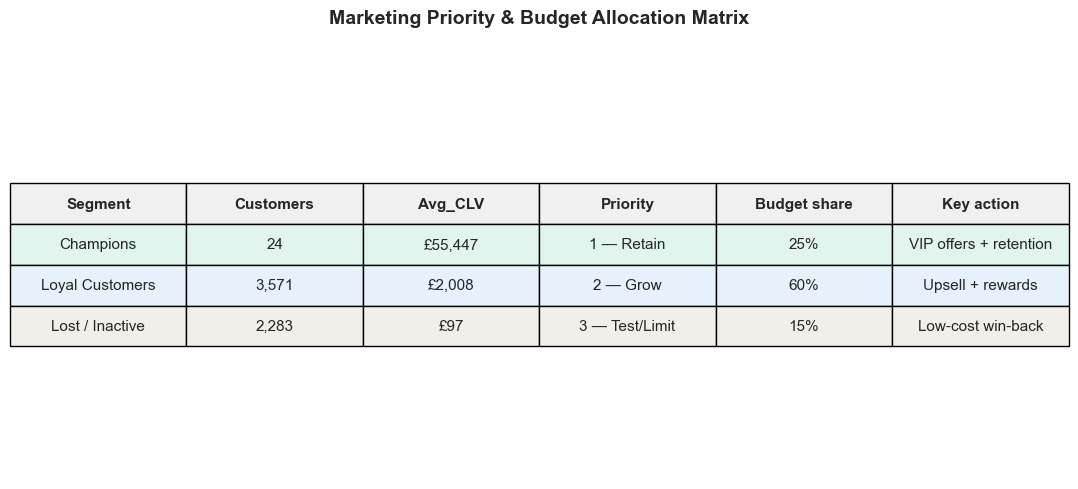

Note: This budget split is an initial recommendation and should be adjusted after campaign testing


In [24]:
# Budget allocation matrix — data-driven marketing strategy summary

# Define segment order
segment_order = ['Champions', 'Loyal Customers', 'Lost / Inactive']

# Create summary from actual RFM data
budget_summary = (
    rfm.groupby('Segment')
       .agg(
           Customers=('Customer ID', 'count'),
           Avg_CLV=('CLV_12m', 'mean')
       )
       .reindex(segment_order)
)

# Add realistic strategy columns
budget_summary['Priority'] = [
    '1 — Retain',
    '2 — Grow',
    '3 — Test/Limit'
]

budget_summary['Budget share'] = [
    '25%',
    '60%',
    '15%'
]

budget_summary['Key action'] = [
    'VIP offers + retention',
    'Upsell + rewards',
    'Low-cost win-back'
]

# Format table for display
budget_display = budget_summary.copy()
budget_display['Customers'] = budget_display['Customers'].map('{:,.0f}'.format)
budget_display['Avg_CLV'] = budget_display['Avg_CLV'].map(lambda x: f'£{x:,.0f}')

# Add Segment as a normal column for the table
budget_display = budget_display.reset_index()

# Create plot area
fig, ax = plt.subplots(figsize=(11, 5))
ax.axis('off')

# Row colours for each segment
row_colors = [
    ['#E1F5EE'] * len(budget_display.columns),   # Champions
    ['#E6F1FB'] * len(budget_display.columns),   # Loyal Customers
    ['#F1EFE8'] * len(budget_display.columns)    # Lost / Inactive
]

# Create table
table = ax.table(
    cellText=budget_display.values,
    colLabels=budget_display.columns,
    cellLoc='center',
    loc='center',
    cellColours=row_colors
)

# Style table
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.3, 2.2)

# Make header row bold and grey
for col in range(len(budget_display.columns)):
    table[(0, col)].set_text_props(fontweight='bold')
    table[(0, col)].set_facecolor('#f0f0f0')

# Add title
ax.set_title(
    'Marketing Priority & Budget Allocation Matrix',
    fontsize=14,
    fontweight='bold',
    pad=20
)

plt.tight_layout()
plt.show()

print("Note: This budget split is an initial recommendation and should be adjusted after campaign testing")